# Decision Tree

In [1]:
import pandas as pd

In [2]:
df=pd.read_csv('DecisionTreeDataset.csv')
df.head()

,CGPA,Communication,Apptitude,Programming Skill,Job Offered
0,High,Good,High,Good,Yes
1,Medium,Good,High,Good,Yes
2,Low,Bad,Low,Good,No
3,Low,Good,Low,Bad,No
4,High,Good,High,Bad,Yes


In [3]:
df.isna().sum()

CGPA                 0
Communication        0
Apptitude            0
Programming Skill    0
Job Offered          0
dtype: int64

In [4]:
df= pd.get_dummies(data=df, drop_first=True)
df.head()

,CGPA_Low,CGPA_Medium,Communication_Good,Apptitude_Low,Programming Skill_Good,Job Offered_Yes
0,False,False,True,False,True,True
1,False,True,True,False,True,True
2,True,False,False,True,True,False
3,True,False,True,True,False,False
4,False,False,True,False,False,True


In [5]:
df.columns

Index(['CGPA_Low', 'CGPA_Medium', 'Communication_Good', 'Apptitude_Low',
       'Programming Skill_Good', 'Job Offered_Yes'],
      dtype='object')

In [6]:
y=df['Job Offered_Yes']
x=df[['CGPA_Low', 'CGPA_Medium', 'Communication_Good', 'Apptitude_Low',
       'Programming Skill_Good']]

In [7]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [9]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(14, 5)
(4, 5)
(14,)
(4,)


In [10]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
model= DecisionTreeClassifier(criterion='entropy', max_depth=5, random_state=42)

In [11]:
model.fit(x_train, y_train)

,criterion,'entropy'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [13]:
y_pred=model.predict(x_test)
y_pred

array([ True,  True, False,  True])

In [14]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test,y_pred)
cm

array([[0, 0],
       [1, 3]])

In [15]:
TN=cm[0][0]
FP=cm[0][1]
FN=cm[1][0]
TP=cm[1][1]

In [16]:
accuracy = (TP+TN)/(TP+TN+FP+FN)
error_rate = (FP+FN)/(TP+TN+FP+FN) 
sensitivity = TP/(TP+FN)
specificity = TN/(TN+FP)

print('accuracy =',accuracy)
print('error rate =',error_rate)
print('sensitivity =',sensitivity)
print('specificity =',specificity)

accuracy = 0.75
error rate = 0.25
sensitivity = 0.75
specificity = nan


C:\Users\LJENG\AppData\Local\Temp\ipykernel_14644\3332953168.py:4: RuntimeWarning: invalid value encountered in scalar divide
  specificity = TN/(TN+FP)


In [20]:
from sklearn.metrics import accuracy_score, recall_score
accuracy=accuracy_score(y_test, y_pred)
print('accuracy =',accuracy)

error_rate=1-accuracy
print('error rate =',error_rate)

sensitivity= recall_score(y_test, y_pred)
print('sensitivity =',sensitivity)

precision=TP/(TP+FP)
print('precision =',precision)

accuracy = 0.75
error rate = 0.25
sensitivity = 0.75
precision = 1.0


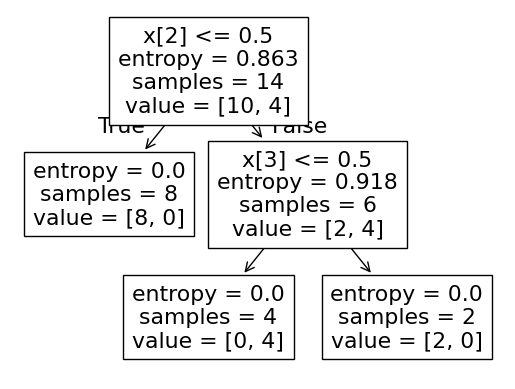

In [21]:
import matplotlib.pyplot as plt
plot_tree(model)
plt.show()

In [22]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

       False       0.00      0.00      0.00         0
        True       1.00      0.75      0.86         4

    accuracy                           0.75         4
   macro avg       0.50      0.38      0.43         4
weighted avg       1.00      0.75      0.86         4



C:\ProgramData\Anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\ProgramData\Anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\ProgramData\Anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [23]:
df=pd.read_csv('diabetes.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [25]:
df.isna().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [26]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [27]:
x=df[['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age']]
y=df['Outcome']

In [38]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [39]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(614, 8)
(154, 8)
(614,)
(154,)


In [40]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
model= DecisionTreeClassifier(criterion='entropy', max_depth=25, random_state=42)

In [41]:
model.fit(x_train, y_train)

,criterion,'entropy'
,splitter,'best'
,max_depth,25
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [42]:
y_pred=model.predict(x_test)
y_pred

array([0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0,
       0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1,
       0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1,
       1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1,
       0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1,
       0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0])

In [43]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test,y_pred)
cm

array([[76, 23],
       [20, 35]])

In [44]:
TN=cm[0][0]
FP=cm[0][1]
FN=cm[1][0]
TP=cm[1][1]

In [46]:
accuracy = (TP+TN)/(TP+TN+FP+FN)
error_rate = (FP+FN)/(TP+TN+FP+FN) 
sensitivity = TP/(TP+FN)
specificity = TN/(TN+FP)
precision=TP/(TP+FP)

print('accuracy =',accuracy)
print('error rate =',error_rate)
print('sensitivity =',sensitivity)
print('specificity =',specificity)
print('precision =',precision)

accuracy = 0.7207792207792207
error rate = 0.2792207792207792
sensitivity = 0.6363636363636364
specificity = 0.7676767676767676
precision = 0.603448275862069


In [47]:
from sklearn.metrics import accuracy_score, recall_score
accuracy=accuracy_score(y_test, y_pred)
print('accuracy =',accuracy)

error_rate=1-accuracy
print('error rate =',error_rate)

sensitivity= recall_score(y_test, y_pred)
print('sensitivity =',sensitivity)

precision=TP/(TP+FP)
print('precision =',precision)

accuracy = 0.7207792207792207
error rate = 0.27922077922077926
sensitivity = 0.6363636363636364
precision = 0.603448275862069
